#### **Data Cleaning & Preparation**

Data cleaning is the process of identifying, correcting, removing, or handling inaccurate, incomplete, inconsistent, and invalid data.

In this notebook, we will transform a raw student-performance dataset into a clean and analysis-ready dataset using Python and Pandas.

The original raw dataset will remain unchanged. All cleaning operations will be performed on the DataFrame, and the final cleaned dataset will be saved separately.

#### **Learning Objectives**

By the end of this notebook, you will be able to:

- Load and inspect a raw dataset
- Identify common data-quality problems
- Convert columns to appropriate data types
- Standardize inconsistent text values
- Detect and handle duplicate records
- Identify and handle missing values
- Validate data using business rules
- Detect statistical outliers using the IQR method
- Distinguish invalid values from statistical outliers
- Apply appropriate treatment to problematic values
- Perform final data-quality validation
- Save the cleaned dataset for further analysis

#### **1. Load the Raw Dataset**

The original student-performance dataset is stored in the `datasets/raw/` folder.

We will load this raw dataset into a Pandas DataFrame.

The raw CSV file will not be modified. After the cleaning process is completed, the cleaned dataset will be saved separately in the `datasets/cleaned/` folder.

In [343]:
import pandas as pd
# Load the dataset 
df = pd.read_csv("../datasets/raw/ITAR_Student_Performance_Dataset_v1.0.csv")

The dataset has now been loaded into the DataFrame `df`.

#### **2. Initial Data Inspection**

Before making any changes to a dataset, it is important to understand its structure, size, columns, data types, and general characteristics.

Initial inspection helps identify potential data-quality problems and guides the cleaning strategy.

In this section, we will use commonly used Pandas functions and attributes to inspect the raw dataset.

##### **2.1 Preview the Dataset**

The `head()` method displays the first five rows of a DataFrame.

It provides a quick overview of the columns, values, and general structure of the dataset.

In [344]:
df.head()

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
0,2024001,Muhammad Khan,Male,20,SE,4,67,80.8,Bannu,1/22/2024,muhammad.khan2024001@itar.edu.pk,Yes,15000.0
1,2024002,Ali Khan,Male,23,DS,6,77,86.6,Kohat,4/30/2024,ali.khan2024002@itar.edu.pk,No,30000.0
2,2024003,Ahmad Khan,Male,18,CS,1,70,85.1,Peshawar,12/8/2024,ahmad.khan2024003@itar.edu.pk,No,50000.0
3,2024004,Hamza Khan,Male,19,DS,2,71,85.2,Bannu,20-03-2024,hamza.khan2024004@itar.edu.pk,No,30000.0
4,2024005,Abdullah Khan,Male,18,AI,1,82,NaN,Mardan,1/1/2024,abdullah.khan2024005@itar.edu.pk,Yes,25000.0


##### **2.2 Dataset Shape**

The `shape` attribute returns the number of rows and columns in the DataFrame.

The result is returned in the following format:

`(rows, columns)`

This helps us understand the size of the dataset before beginning the cleaning process.

In [345]:
df.shape

(150, 13)

##### **2.3 Column Names**

The `columns` attribute returns the names of all columns in the DataFrame.

Examining column names helps us understand which variables are available and identify any naming issues that may need attention.

In [346]:
df.columns

Index(['student_id', 'full_name', 'gender', 'age', 'department', 'semester',
       'marks', 'attendance_percentage', 'city', 'admission_date', 'email',
       'scholarship', 'tuition_fee'],
      dtype='str')

##### **2.4 Data Types**

The `dtypes` attribute displays the current data type of each column.

Checking data types is important because values may sometimes be stored using an inappropriate type, such as numbers stored as text.

We will correct data types later in the data-cleaning process.

In [347]:
df.dtypes

student_id                 int64
full_name                    str
gender                       str
age                          str
department                   str
semester                   int64
marks                        str
attendance_percentage    float64
city                         str
admission_date               str
email                        str
scholarship                  str
tuition_fee              float64
dtype: object

##### **2.5 Dataset Information**

The `info()` method provides a concise summary of the DataFrame.

It includes:

- Column names
- Number of non-null values
- Data types
- Memory usage

This information helps us identify missing values and columns that may require data-type conversion.

In [348]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             150 non-null    int64  
 1   full_name              150 non-null    str    
 2   gender                 148 non-null    str    
 3   age                    147 non-null    str    
 4   department             150 non-null    str    
 5   semester               150 non-null    int64  
 6   marks                  142 non-null    str    
 7   attendance_percentage  104 non-null    float64
 8   city                   150 non-null    str    
 9   admission_date         148 non-null    str    
 10  email                  145 non-null    str    
 11  scholarship            149 non-null    str    
 12  tuition_fee            147 non-null    float64
dtypes: float64(2), int64(2), str(9)
memory usage: 15.4 KB


##### **2.6 Descriptive Statistics**

The `describe()` method provides a statistical summary of numerical columns.

The output includes:

- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median (50th percentile)
- 75th percentile
- Maximum

These statistics provide a quick overview of numerical variables and may help identify unusual values that require further investigation.

In [349]:
df.describe()

,student_id,semester,attendance_percentage,tuition_fee
count,1.500000e+02,150.000000,104.000000,147.000000
mean,2.024071e+06,4.366667,83.975000,27176.870748
std,4.224882e+01,3.244855,14.232915,11119.956564
min,2.024001e+06,1.000000,-5.000000,15000.000000
25%,2.024035e+06,2.000000,82.875000,15000.000000
50%,2.024070e+06,4.000000,87.050000,30000.000000
75%,2.024108e+06,6.000000,91.125000,30000.000000
max,2.024145e+06,30.000000,105.000000,50000.000000


#### **Initial Inspection Summary**

At this stage, we have inspected the raw dataset without modifying it.

We now have information about:

- Dataset size
- Available columns
- Current data types
- Missing/non-null values
- Basic numerical statistics

This information will guide the next stage of the data-cleaning process.

#### **3. Data Type Conversion**

Correct data types are important for reliable data analysis.

Raw datasets may contain numbers stored as text, dates stored as strings, or other values that are not represented using an appropriate data type.

In this section, we will:

- Identify columns that require conversion
- Convert numeric columns to numeric data types
- Convert date columns to datetime
- Safely handle values that cannot be converted
- Verify the resulting data types

Data type conversion is performed before further cleaning and analysis so that subsequent operations work correctly.

##### **3.1 Converting Numeric Columns**

Numeric columns should be stored using an appropriate numeric data type so that mathematical and statistical operations can be performed correctly.

The `pd.to_numeric()` function converts values into numeric format.

We use `errors="coerce"` when a column may contain invalid values. Values that cannot be converted are replaced with `NaN`, which can then be handled during the missing-value stage.

In [350]:
df["marks"] = pd.to_numeric(
    df["marks"],
    errors="coerce"
)

df["age"] = pd.to_numeric(
    df["age"],
    errors="coerce"
)

df["tuition_fee"] = pd.to_numeric(
    df["tuition_fee"],
    errors="coerce"
)

df["attendance_percentage"] = pd.to_numeric(
    df["attendance_percentage"],
    errors="coerce"
)

##### **3.2 Converting the Date Column**

Dates are often imported from CSV files as text.

The `pd.to_datetime()` function converts a column into Pandas datetime format, allowing the values to be handled as actual dates.

The student-performance dataset uses the `MM/DD/YYYY` format, so we specify the format explicitly.

In [351]:
df["admission_date"] = pd.to_datetime(
    df["admission_date"],
    format="%m/%d/%Y",
    errors="coerce"
)

##### **3.3 Handling Conversion Errors**

Real-world datasets may contain invalid values.

For example, a numeric column might contain values such as:

- `85`
- `91`
- `Absent`
- `88`

When `errors="coerce"` is used, valid numeric values remain unchanged, while values that cannot be converted become `NaN`.

These resulting missing values can be handled later during the missing-value stage.

#### **3.4 Verify the Data Types**

After converting the columns, we should verify the resulting data types.

The `dtypes` attribute allows us to confirm whether the columns are now stored using appropriate data types.

In [352]:
df.dtypes

student_id                        int64
full_name                           str
gender                              str
age                             float64
department                          str
semester                          int64
marks                           float64
attendance_percentage           float64
city                                str
admission_date           datetime64[us]
email                               str
scholarship                         str
tuition_fee                     float64
dtype: object

#### **4. Data Quality Assessment**

After inspecting the dataset, the next step is to assess its data quality.

Data quality assessment is the process of identifying problems that may affect the accuracy and reliability of data analysis.

Common data-quality issues include:

- Missing values
- Duplicate records
- Inconsistent text
- Invalid values
- Incorrect data types
- Statistical outliers

At this stage, we will identify and investigate potential problems before deciding how to handle them.

> **Important:** Do not automatically modify or delete data simply because a value appears unusual. First understand the problem and determine the appropriate treatment.

##### **4.1 Checking for Missing Values**

Missing values occur when information is unavailable, unknown, or has not been recorded.

Before deciding how to handle missing values, we first need to determine:

- Which columns contain missing values?
- How many values are missing?
- What percentage of each column is missing?

This information will help us choose an appropriate missing-value strategy later.

In [353]:
df.isnull().sum()

student_id                0
full_name                 0
gender                    2
age                       4
department                0
semester                  0
marks                    11
attendance_percentage    46
city                      0
admission_date            6
email                     5
scholarship               1
tuition_fee               3
dtype: int64

The `isnull()` method identifies missing values in the DataFrame.

Using `.sum()` after `isnull()` counts the number of missing values in each column.

This allows us to quickly identify which columns require further investigation.

In [354]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage

student_id                0.000000
full_name                 0.000000
gender                    1.333333
age                       2.666667
department                0.000000
semester                  0.000000
marks                     7.333333
attendance_percentage    30.666667
city                      0.000000
admission_date            4.000000
email                     3.333333
scholarship               0.666667
tuition_fee               2.000000
dtype: float64

##### **Missing Value Percentage**

The number of missing values alone does not always show the severity of a data-quality problem.

Calculating the percentage of missing values helps us understand how much information is missing from each column.

For example, a column with 2% missing values may require a different treatment from a column with 30% missing values.

The appropriate decision should consider both the amount of missing data and the importance of the column.

##### **4.2 Checking for Duplicate Records**

Duplicate records occur when the same information appears more than once in a dataset.

Duplicates may be caused by:

- Repeated data entry
- System errors
- Data migration
- Combining data from multiple sources

Duplicate records can affect calculations and may lead to inaccurate analysis.

However, not every repeated record is necessarily an error. Before removing duplicates, we should investigate whether they represent accidental duplication or valid observations.

In [355]:
df.duplicated().sum()

np.int64(5)

The `duplicated()` method identifies duplicate rows.

Using `.sum()` counts how many duplicate rows are present in the DataFrame.

A result of `0` means that no duplicate rows were detected.

In [356]:
df[df.duplicated(keep=False)]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
2,2024003,Ahmad Khan,Male,18.0,CS,1,70.0,85.1,Peshawar,2024-12-08,ahmad.khan2024003@itar.edu.pk,No,50000.0
10,2024011,Muhammad Ahmad,Male,18.0,IT,1,80.0,NaN,Kohat,2024-05-25,muhammad.ahmad2024011,No,50000.0
25,2024026,Ali Ahmad,Male,25.0,AI,8,105.0,51.3,Bannu,2024-01-25,ali.ahmad2024026@ali.ahmad2024026@itar.edu.pk,Yes,15000.0
40,2024041,Ahmad Ahmad,Male,25.0,IT,7,-10.0,NaN,Mardan,2024-02-23,ahmad.ahmad2024041@ahmad.ahmad2024041@itar.edu.pk,No,30000.0
55,2024056,Naveed Khan,Male,19.0,CS,3,NaN,92.2,Mardan,2024-01-08,naveed.khan2024056@naveed.khan2024056@itar.edu.pk,Yes,15000.0
145,2024003,Ahmad Khan,Male,18.0,CS,1,70.0,85.1,Peshawar,2024-12-08,ahmad.khan2024003@itar.edu.pk,No,50000.0
146,2024011,Muhammad Ahmad,Male,18.0,IT,1,80.0,NaN,Kohat,2024-05-25,muhammad.ahmad2024011,No,50000.0
147,2024026,Ali Ahmad,Male,25.0,AI,8,105.0,51.3,Bannu,2024-01-25,ali.ahmad2024026@ali.ahmad2024026@itar.edu.pk,Yes,15000.0
148,2024041,Ahmad Ahmad,Male,25.0,IT,7,-10.0,NaN,Mardan,2024-02-23,ahmad.ahmad2024041@ahmad.ahmad2024041@itar.edu.pk,No,30000.0
149,2024056,Naveed Khan,Male,19.0,CS,3,NaN,92.2,Mardan,2024-01-08,naveed.khan2024056@naveed.khan2024056@itar.edu.pk,Yes,15000.0


##### **Reviewing Duplicate Records**

Before removing duplicates, it is useful to display the duplicate records.

The argument `keep=False` marks all records belonging to a duplicated group as duplicates.

This allows us to inspect the records and determine whether the duplication appears to be accidental.

#### **4.3 Checking for Inconsistent Text**

Text values can contain inconsistencies caused by:

- Different capitalization
- Leading or trailing spaces
- Abbreviations
- Different spellings
- Unnecessary punctuation
- Different representations of the same category

For example, the following values may represent the same category:

`Male`, `male`, `M`, and ` m `

Before standardizing these values, we should first inspect the unique values in the categorical columns.

In [357]:
print("Gender:")
print(df["gender"].unique())

Gender:
<StringArray>
['Male', nan, 'Female', 'male', 'MALE', 'M', 'female', 'F', 'm', 'f']
Length: 10, dtype: str


In [358]:
print("\nDepartment:")
print(df["department"].unique())


Department:
<StringArray>
[          'SE',           'DS',           'CS',           'AI',
           'IT', 'Software Eng', 'Computer Sci',           'cs',
 'Data Science',          'A I',          'S.E',         'A.I.',
          'A.I']
Length: 13, dtype: str


In [359]:
print("\nCity:")
print(df["city"].unique())


City:
<StringArray>
[           'Bannu',            'Kohat',         'Peshawar',
           'Mardan', 'Dera Ismail Khan',        'Islamabad',
           'Lahore',           'Quetta',             'Swat',
          'Karachi']
Length: 10, dtype: str


In [360]:
print("\nScholarship:")
print(df["scholarship"].unique())


Scholarship:
<StringArray>
['Yes', 'No', nan]
Length: 3, dtype: str


The `unique()` method displays the distinct values in a column.

Inspecting unique values helps us identify inconsistent representations before applying standardization rules.

We will standardize the identified text values in the next cleaning stage.

#### **4.4 Checking for Invalid Values**

A value can be present and have the correct data type but still be invalid.

For example:

- Marks outside the valid range
- Age outside the expected student-age range
- Attendance below 0% or above 100%
- Invalid semester numbers
- Non-positive tuition fees

These values should be checked using appropriate business rules.

At this stage, we identify the potential problems. We will decide how to treat them later.

In [361]:
print("Marks outside 0–100:")
df[(df["marks"] < 0) | (df["marks"] > 100)]

Marks outside 0–100:


,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
25,2024026,Ali Ahmad,Male,25.0,AI,8,105.0,51.3,Bannu,2024-01-25,ali.ahmad2024026@ali.ahmad2024026@itar.edu.pk,Yes,15000.0
40,2024041,Ahmad Ahmad,Male,25.0,IT,7,-10.0,NaN,Mardan,2024-02-23,ahmad.ahmad2024041@ahmad.ahmad2024041@itar.edu.pk,No,30000.0
132,2024133,Sadia Bibi,Female,23.0,IT,5,105.0,91.6,Dera Ismail Khan,2024-08-04,sadia.bibi2024133@sadia.bibi2024133@itar.edu.pk,No,30000.0
136,2024137,Farhan Ali,Male,22.0,CS,4,-10.0,94.3,Bannu,2024-05-10,farhan.ali2024137,Yes,15000.0
147,2024026,Ali Ahmad,Male,25.0,AI,8,105.0,51.3,Bannu,2024-01-25,ali.ahmad2024026@ali.ahmad2024026@itar.edu.pk,Yes,15000.0
148,2024041,Ahmad Ahmad,Male,25.0,IT,7,-10.0,NaN,Mardan,2024-02-23,ahmad.ahmad2024041@ahmad.ahmad2024041@itar.edu.pk,No,30000.0


In [362]:
print("\nAttendance outside 0–100:")
df[(df["attendance_percentage"] < 0) | (df["attendance_percentage"] > 100)]


Attendance outside 0–100:


,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
71,2024072,Muhammad Ali,Male,18.0,IT,2,77.0,-5.0,Dera Ismail Khan,2024-11-08,muhammad.ali2024072,No,30000.0
106,2024107,Iqra Bibi,Female,19.0,CS,1,83.0,105.0,Quetta,2024-03-29,iqra.bibi2024107@iqra.bibi2024107@itar.edu.pk,No,50000.0


In [363]:
print("\nAge outside 18–25:")
df[(df["age"] < 18) | (df["age"] > 25)]


Age outside 18–25:


,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
5,2024006,Hassan Khan,NaN,-5.0,CS,5,95.0,93.4,Peshawar,2024-08-03,hassan.khan2024006@itar.edu.pk,Yes,15000.0
18,2024019,Zainab Khan,Female,150.0,AI,30,78.0,81.5,Kohat,NaT,zainab.khan2024019@itar.edu.pk,Yes,NaN
49,2024050,Ahsan Khan,Male,200.0,AI,7,85.0,84.2,Mardan,2024-04-25,ahsan.khan2024050@ahsan.khan2024050@itar.edu.pk,No,30000.0
80,2024081,Fiza Khan,Female,32.0,SE,5,72.0,82.4,Peshawar,2024-02-21,fiza.khan2024081,No,30000.0


In [364]:
print("\nInvalid semester:")
df[(df["semester"] < 1) | (df["semester"] > 8)]


Invalid semester:


,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
6,2024007,Bilal Khan,Male,22.0,AI,15,83.0,85.5,Dera Ismail Khan,2024-11-04,bilal.khan2024007@itar.edu.pk,No,NaN
18,2024019,Zainab Khan,Female,150.0,AI,30,78.0,81.5,Kohat,NaT,zainab.khan2024019@itar.edu.pk,Yes,NaN
110,2024111,Arslan Ali,Male,19.0,IT,10,81.0,82.5,Quetta,2024-09-03,arslan.ali2024111,Yes,NaN


In [365]:
print("Non-positive tuition fee:")
df[df["tuition_fee"] <= 0]

Non-positive tuition fee:


,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee


These checks identify values that may violate the expected rules of the student-performance dataset.

At this stage, we are only identifying potential problems.

We will not automatically delete these records. The appropriate treatment will be determined in the Business Rule Validation section.

### **Data Quality Assessment Summary**

The initial assessment has identified the main areas that require attention:

- Missing values
- Duplicate records
- Inconsistent categorical text
- Potentially invalid numerical values
- Potential statistical outliers

The next sections will address these issues systematically.

The general principle is:

**Identify → Investigate → Decide → Clean → Validate**

#### **5. Handling Inconsistent Text**

Text values in a dataset may be inconsistent because of differences in:

- Capitalization
- Leading or trailing spaces
- Abbreviations
- Punctuation
- Spelling
- Different representations of the same category

Inconsistent text can cause the same category to be treated as multiple different values.

For example:

`Male`, `male`, `M`, and ` m ` may all represent the same category.

In this section, we will standardize the categorical text values identified during the data-quality assessment.

##### **5.1 Standardizing Gender Values**

The `gender` column may contain different representations of the same category.

We will:

1. Remove leading and trailing spaces.
2. Convert the values to lowercase.
3. Replace known abbreviations with standardized category names.

In [366]:
df["gender"] = (
    df["gender"]
    .str.strip()
    .str.lower()
)

df["gender"] = df["gender"].replace({
    "m": "male",
    "f": "female"
})

##### **Verify Gender Values**

After standardizing the values, we should verify the unique categories.

In [367]:
df["gender"].unique()

<StringArray>
['male', nan, 'female']
Length: 3, dtype: str

##### **5.2 Standardizing Department Values**

Department names may be represented using different formats.

For example, the same department may appear with:

- Different capitalization
- Spaces
- Punctuation
- Abbreviations

We will standardize the values before mapping known variations to consistent department codes.

In [368]:
df["department"] = (
    df["department"]
    .str.strip()                               # Step 1: Remove leading/trailing spaces
    .str.upper()                               # Step 2: Convert to uppercase
    .str.replace(".", "", regex=False)         # Step 3: Remove dots
    .str.replace(" ", "", regex=False)         # Step 4: Remove spaces
)

##### **Mapping Department Variations**

After basic text standardization, we can map known variations to consistent department codes.

The mapping rules should be based on the actual values found in the dataset.

In [369]:
df["department"] = df["department"].replace({
    "SOFTWAREENG": "SE",
    "COMPUTERSCI": "CS",
    "DATASCIENCE": "DS"
})

##### **Verify Department Values**

We can use `unique()` to confirm that the department values have been standardized.

In [370]:
df['department'].unique()

<StringArray>
['SE', 'DS', 'CS', 'AI', 'IT']
Length: 5, dtype: str

##### **5.3 Reviewing Other Text Columns**

Other text columns should be reviewed individually.

Different columns may require different cleaning rules.

For example:

- Names may require whitespace standardization.
- Email addresses may require lowercase conversion and whitespace removal.
- City names may require capitalization standardization.
- Categorical variables may require mapping to consistent category names.

We should avoid applying the same transformation to every text column because each variable has its own meaning and formatting requirements.

##### **5.4 Standardizing Email Addresses**

Email addresses are generally case-insensitive for practical data-cleaning purposes.

We can remove unnecessary spaces and convert the values to lowercase.

Missing values will remain missing and will be handled later in the Missing Values section.

In [371]:
df["email"] = (
    df["email"]
    .str.strip()
    .str.lower()
)

In [372]:
df["email"].head()

0    muhammad.khan2024001@itar.edu.pk
1         ali.khan2024002@itar.edu.pk
2       ahmad.khan2024003@itar.edu.pk
3       hamza.khan2024004@itar.edu.pk
4    abdullah.khan2024005@itar.edu.pk
Name: email, dtype: str

##### **5.5 Standardizing City Names**

City names may contain inconsistent capitalization or unnecessary spaces.

We can standardize the formatting while preserving the actual city names.

In [373]:
df["city"] = (
    df["city"]
    .str.strip()
    .str.title()
)

In [374]:
df["city"].unique()

<StringArray>
[           'Bannu',            'Kohat',         'Peshawar',
           'Mardan', 'Dera Ismail Khan',        'Islamabad',
           'Lahore',           'Quetta',             'Swat',
          'Karachi']
Length: 10, dtype: str

##### **5.6 Verify Text Standardization**

After applying the cleaning rules, we should inspect the unique values again.

This helps confirm that known inconsistencies have been standardized and that no unexpected categories were introduced.

In [375]:
print("Gender:")
print(df["gender"].unique())

print("\nDepartment:")
print(df["department"].unique())

print("\nCity:")
print(df["city"].unique())

print("\nScholarship:")
print(df["scholarship"].unique())

Gender:
<StringArray>
['male', nan, 'female']
Length: 3, dtype: str

Department:
<StringArray>
['SE', 'DS', 'CS', 'AI', 'IT']
Length: 5, dtype: str

City:
<StringArray>
[           'Bannu',            'Kohat',         'Peshawar',
           'Mardan', 'Dera Ismail Khan',        'Islamabad',
           'Lahore',           'Quetta',             'Swat',
          'Karachi']
Length: 10, dtype: str

Scholarship:
<StringArray>
['Yes', 'No', nan]
Length: 3, dtype: str


#### **6. Handling Duplicate Records**

Duplicate records occur when the same information appears more than once in a dataset.

Duplicates may be caused by:

- Repeated data entry
- System errors
- Data import problems
- Combining data from multiple sources

Duplicate records can affect statistical calculations and may lead to misleading analysis.

However, not every repeated record is an error.

Before removing duplicates, a data analyst should understand why the records are repeated and whether they represent legitimate observations.

##### **6.1 Detecting and Count Duplicate Records**

The `duplicated()` method identifies rows that are duplicates of previously occurring rows.

Using `.sum()` converts the Boolean results into a count.

A result of `0` means that no duplicate rows were detected.

By default, the first occurrence is considered the original record, while subsequent identical rows are marked as duplicates.

In [376]:
df.duplicated().sum()

np.int64(5)

##### **6.2 Reviewing Duplicate Records**

Before removing duplicates, we should inspect the actual records.

The argument `keep=False` marks all records belonging to a duplicated group as duplicates.

This allows us to see every record involved in the duplication rather than viewing only the later occurrence.

In [377]:
duplicate_rows = df[
    df.duplicated(keep=False)
]

duplicate_rows

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
2,2024003,Ahmad Khan,male,18.0,CS,1,70.0,85.1,Peshawar,2024-12-08,ahmad.khan2024003@itar.edu.pk,No,50000.0
10,2024011,Muhammad Ahmad,male,18.0,IT,1,80.0,NaN,Kohat,2024-05-25,muhammad.ahmad2024011,No,50000.0
25,2024026,Ali Ahmad,male,25.0,AI,8,105.0,51.3,Bannu,2024-01-25,ali.ahmad2024026@ali.ahmad2024026@itar.edu.pk,Yes,15000.0
40,2024041,Ahmad Ahmad,male,25.0,IT,7,-10.0,NaN,Mardan,2024-02-23,ahmad.ahmad2024041@ahmad.ahmad2024041@itar.edu.pk,No,30000.0
55,2024056,Naveed Khan,male,19.0,CS,3,NaN,92.2,Mardan,2024-01-08,naveed.khan2024056@naveed.khan2024056@itar.edu.pk,Yes,15000.0
145,2024003,Ahmad Khan,male,18.0,CS,1,70.0,85.1,Peshawar,2024-12-08,ahmad.khan2024003@itar.edu.pk,No,50000.0
146,2024011,Muhammad Ahmad,male,18.0,IT,1,80.0,NaN,Kohat,2024-05-25,muhammad.ahmad2024011,No,50000.0
147,2024026,Ali Ahmad,male,25.0,AI,8,105.0,51.3,Bannu,2024-01-25,ali.ahmad2024026@ali.ahmad2024026@itar.edu.pk,Yes,15000.0
148,2024041,Ahmad Ahmad,male,25.0,IT,7,-10.0,NaN,Mardan,2024-02-23,ahmad.ahmad2024041@ahmad.ahmad2024041@itar.edu.pk,No,30000.0
149,2024056,Naveed Khan,male,19.0,CS,3,NaN,92.2,Mardan,2024-01-08,naveed.khan2024056@naveed.khan2024056@itar.edu.pk,Yes,15000.0


#### **Think Like a Data Analyst**

Before removing duplicate records, ask:

1. Are the records accidentally duplicated?
2. Are the records completely identical?
3. Is there a unique identifier such as `student_id`?
4. Could the repeated records represent legitimate events?
5. Which record should be retained if the information is different?
6. Will removing the records affect the analysis?

The answers to these questions determine the appropriate duplicate-handling strategy.

##### **6.3 Common Duplicate Handling Strategies**

Different situations require different strategies.

| Situation | Possible Strategy |
|---|---|
| Completely identical records | Remove duplicate records |
| Updated information exists | Keep the most recent record |
| Duplicate based on a primary key | Investigate before removing |
| Legitimate transactions | Keep the records |
| Duplicate caused by data import | Remove after verification |

There is no single duplicate-handling method that is correct for every dataset.

##### **6.4 Removing Exact Duplicate Records**

If duplicate rows are completely identical and our investigation confirms that they are accidental duplicates, we can remove the extra records.

The `drop_duplicates()` method removes duplicate rows and keeps the first occurrence by default.

We will first create a cleaned copy instead of modifying the original DataFrame immediately.

In [378]:
df_clean = df.drop_duplicates()

##### **6.5 Comparing the Dataset Before and After Removing Duplicates**

After removing duplicates, we should compare the number of rows before and after the operation.

This allows us to verify how many records were removed.

In [379]:
print("Rows before removing duplicates:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Duplicates removed:", len(df) - len(df_clean))

Rows before removing duplicates: 150
Rows after removing duplicates: 145
Duplicates removed: 5


##### **6.6 Verifying Duplicate Removal**

After removing duplicates, we should verify that the cleaned DataFrame no longer contains exact duplicate rows.

In [380]:
df_clean.duplicated().sum()

np.int64(0)

#### **6.7 Updating the Working DataFrame**

The duplicate records have now been reviewed, removed, and verified.

We can now use the cleaned DataFrame `df_clean` as the working DataFrame for the remaining cleaning steps.

The original raw CSV file remains unchanged.

In [381]:
df = df_clean.copy()

#### **7. Handling Missing Values**

Missing values occur when information is unavailable, unknown, or has not been recorded.

Missing values are common in real-world datasets and should be handled carefully.

Before filling or removing missing values, we should determine:

- Which columns contain missing values?
- How many values are missing?
- What percentage of each column is missing?
- Is the column numerical, categorical, text-based, or date-based?
- Are there outliers in the numerical column?
- Does the missing value have a specific business meaning?
- Would removing the records affect the analysis?

There is no single missing-value method that is appropriate for every column.

The general principle is:

**Identify → Measure → Understand → Choose a Method → Apply → Validate**

##### **7.1 Identifying Missing Values**

We first count the missing values in each column.

The `isnull()` method identifies missing values, while `.sum()` counts the number of missing values in each column.

In [382]:
df.isnull().sum()

student_id                0
full_name                 0
gender                    2
age                       4
department                0
semester                  0
marks                    10
attendance_percentage    44
city                      0
admission_date            6
email                     5
scholarship               1
tuition_fee               3
dtype: int64

##### **7.2 Calculating Missing-Value Percentage**

The number of missing values alone does not tell us how serious the problem is.

For example, 5 missing values may be insignificant in a dataset containing thousands of records but important in a dataset containing only 50 records.

Therefore, we calculate the percentage of missing values for each column.

In [383]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

missing_summary

,Missing Values,Missing Percentage
student_id,0,0.000000
full_name,0,0.000000
gender,2,1.379310
age,4,2.758621
department,0,0.000000
semester,0,0.000000
marks,10,6.896552
attendance_percentage,44,30.344828
city,0,0.000000
admission_date,6,4.137931


##### **7.3 Reviewing Columns with Missing Values**

To focus our analysis, we can display only the columns that contain missing values.

In [384]:
missing_summary[
    missing_summary["Missing Values"] > 0
]

,Missing Values,Missing Percentage
gender,2,1.379310
age,4,2.758621
marks,10,6.896552
attendance_percentage,44,30.344828
admission_date,6,4.137931
email,5,3.448276
scholarship,1,0.689655
tuition_fee,3,2.068966


##### **7.4 Choosing a Missing-Value Strategy**

Different variables require different approaches.

For this student-performance dataset, we will consider the nature of each column before selecting a method.

| Column | Type | Strategy |
|---|---|---|
| Marks | Numerical | Mean, if distribution and outliers are appropriate |
| Attendance Percentage | Numerical | Investigate before filling |
| Tuition Fee | Numerical | Median |
| Gender | Categorical | Mode |
| Email | Text | `"Not Available"` |
| Admission Date | Date | Investigate first |

The selected strategy should be based on the characteristics and meaning of each variable rather than simply choosing a Pandas function.

##### **7.5 Filling Missing Gender Values**

`gender` is a categorical variable.

The mean and median are not appropriate for categorical data. The mode is commonly used because it represents the most frequently occurring category.

We will replace missing gender values with the most frequent gender in the dataset.

In [385]:
df["gender"] = df["gender"].fillna(
    df["gender"].mode()[0]
)

In [386]:
df["gender"].isnull().sum()

np.int64(0)

##### **7.6 Filling Missing Marks**

`marks` is a numerical variable.

The source case study recommends using the mean when only a small number of values are missing and the marks are approximately normally distributed without significant outliers.

Before applying the mean, we should therefore consider the distribution and outliers of the marks column.

For this educational dataset, we will use the mean as the demonstrated imputation method under these assumptions.

In [387]:
marks_mean = df["marks"].mean()

df["marks"] = df["marks"].fillna(
    marks_mean
)

The mean is calculated from the available marks and then used to replace missing values.

After filling the missing values, we should verify the result.

In [388]:
df["marks"].isnull().sum()

np.int64(0)

##### **7.7 Filling Missing Tuition Fees**

`tuition_fee` is a numerical variable.

The source recommends using the median for tuition fees because extreme values may occur due to differences in scholarships, fee waivers, or academic programs.

The median is less affected by extreme values than the mean.

In [389]:
tuition_median = df["tuition_fee"].median()

df["tuition_fee"] = df["tuition_fee"].fillna(
    tuition_median
)

In [390]:
df["tuition_fee"].isnull().sum()

np.int64(0)

##### **7.8 Handling Missing Email Addresses**

An email address is a text field rather than a numerical variable.

We should not use mean, median, or mode to create an email address.

Instead, the source recommends using a clear constant value such as `"Not Available"` to indicate that the email address was not provided.

This preserves the record while clearly showing that the information is unavailable.

In [391]:
df["email"] = df["email"].fillna(
    "Not Available"
)

In [392]:
df["email"].isnull().sum()

np.int64(0)

##### **7.9 Attendance Percentage: Investigate Before Filling**

The `attendance_percentage` column contains a relatively large proportion of missing values.

When a substantial percentage of a variable is missing, automatically replacing all missing values with the mean or median may distort the distribution and reduce the quality of the analysis.

Therefore, we will not automatically fill these values at this stage.

Instead, we should investigate why the attendance values are missing and whether the missingness is related to factors such as semester or department.

This is an example of professional data-cleaning practice:

**Do not impute first and investigate later. Investigate first.**

In [393]:
df[df["attendance_percentage"].isnull()][
    ["student_id", "department", "semester"]
]

,student_id,department,semester
4,2024005,AI,1
9,2024010,IT,1
10,2024011,IT,1
11,2024012,SE,4
14,2024015,CS,8
16,2024017,CS,4
19,2024020,CS,6
21,2024022,IT,7
23,2024024,SE,1
30,2024031,SE,7


##### **7.10 Admission Date: Investigate Before Filling**

`admission_date` represents an actual historical event.

Therefore, we should not replace a missing admission date with an arbitrary date or use forward fill simply because the previous row contains a date.

The correct date should ideally be obtained from the original source or another reliable record.

For this reason, missing admission dates will remain missing until a valid source or business rule provides the correct value.

In [394]:
df[df["admission_date"].isnull()][
    ["student_id", "full_name", "admission_date"]
]

,student_id,full_name,admission_date
3,2024004,Hamza Khan,NaT
7,2024008,Fatima Khan,NaT
14,2024015,Danish Khan,NaT
18,2024019,Zainab Khan,NaT
104,2024105,Sohail Ali,NaT
142,2024143,Asif Ali,NaT


##### **Why We Are Not Using Forward Fill**

Forward fill (`ffill`) replaces a missing value with the previous valid value.

This technique is appropriate for time-series or sequential data where neighboring observations are logically connected.

However, students are independent observations.

Therefore, one student's admission date, age, marks, or tuition fee should not automatically be assigned to another student.

For this reason, we will not use `ffill()` for these student-level variables.

##### **7.11 Verify Missing Values**

After applying the selected missing-value strategies, we should check the remaining missing values.

Some missing values may intentionally remain because they require further investigation rather than automatic imputation.

In [395]:
df.isnull().sum()

student_id                0
full_name                 0
gender                    0
age                       4
department                0
semester                  0
marks                     0
attendance_percentage    44
city                      0
admission_date            6
email                     0
scholarship               1
tuition_fee               0
dtype: int64

##### **7.12 Filling Remaining Missing Values**
After verifying the remaining missing values, the next step is to handle them appropriately.

Different columns require different strategies depending on their data type and meaning.

For this dataset:

- `age` will be filled using the median.
- `attendance_percentage` will be filled using the median.
- `admission_date` will be retained as missing because it represents a historical event whose original value is unknown.
- `scholarship` will be filled using the mode.

Median is preferred for the numerical columns because it is less affected by extreme values than the mean.

The mode is appropriate for the categorical `scholarship` column.

For `admission_date`, we do not artificially assign a value because doing so would introduce information that was not present in the original dataset.

In [396]:
# Fill missing age values with the median

df["age"] = df["age"].fillna(df["age"].median())

In [397]:
# Fill missing attendance values with the median

df["attendance_percentage"] = df["attendance_percentage"].fillna(
    df["attendance_percentage"].median()
)

In [398]:
# 

df["admission_date"].isnull().sum()

np.int64(6)

`Missing admission dates are retained because the original historical event is unknown. Artificially assigning the mode would introduce information that was not present in the original dataset.`

In [399]:
# Fill missing scholarship values with the mode

df["scholarship"] = df["scholarship"].fillna(
    df["scholarship"].mode()[0]
)

In [400]:
# Check remaining missing values

df.isnull().sum()

student_id               0
full_name                0
gender                   0
age                      0
department               0
semester                 0
marks                    0
attendance_percentage    0
city                     0
admission_date           6
email                    0
scholarship              0
tuition_fee              0
dtype: int64

##### **7.13 Data Validation**

After handling all missing values, the next step is to validate the dataset.

Data validation checks whether the values follow the predefined rules and expected ranges of the dataset.

A dataset may contain invalid or inconsistent values even when there are no missing values or duplicate records.

In this section, we will check:

- Numeric ranges
- Categorical values
- Department names
- Student ages
- Semester values
- Marks
- Attendance percentage
- Tuition fee
- Scholarship values

The validation rules are based on the dataset's data dictionary.

##### **7.13.1 Validating Student Age**

The age column should contain realistic student ages according to the dataset rules.

The defined valid range is `18–25` years.

We will identify records outside this range before deciding how to correct them.

In [401]:
# Check for invalid age values

df[~df["age"].between(18, 25)]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
5,2024006,Hassan Khan,male,-5.0,CS,5,95.0,93.4,Peshawar,2024-08-03,hassan.khan2024006@itar.edu.pk,Yes,15000.0
18,2024019,Zainab Khan,female,150.0,AI,30,78.0,81.5,Kohat,NaT,zainab.khan2024019@itar.edu.pk,Yes,30000.0
49,2024050,Ahsan Khan,male,200.0,AI,7,85.0,84.2,Mardan,2024-04-25,ahsan.khan2024050@ahsan.khan2024050@itar.edu.pk,No,30000.0
80,2024081,Fiza Khan,female,32.0,SE,5,72.0,82.4,Peshawar,2024-02-21,fiza.khan2024081,No,30000.0


##### **Correcting Invalid Age Values**

The validation step identified age values outside the valid range of 18–25 years.

These values are considered invalid because they do not represent realistic student ages.

Instead of deleting the affected records, we will replace the invalid ages with the median age calculated from the valid age values.

Using the median helps reduce the influence of unusually high or low values.

In [402]:
median_age = df.loc[
    df["age"].between(18, 25),
    "age"
].median()

df.loc[
    ~df["age"].between(18, 25),
    "age"
] = median_age

In [403]:
# Check whether any invalid age values remain

df[~df["age"].between(18, 25)]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee


##### **7.13.2 Validating Semester**

The `semester` column represents the student's current academic semester.

According to the dataset rules, valid semester values range from 1 to 8.

We will identify any values outside this range and correct them if necessary.

In [404]:
# Identify invalid semester values

df[~df["semester"].between(1, 8)]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
6,2024007,Bilal Khan,male,22.0,AI,15,83.0,85.5,Dera Ismail Khan,2024-11-04,bilal.khan2024007@itar.edu.pk,No,30000.0
18,2024019,Zainab Khan,female,21.0,AI,30,78.0,81.5,Kohat,NaT,zainab.khan2024019@itar.edu.pk,Yes,30000.0
110,2024111,Arslan Ali,male,19.0,IT,10,81.0,82.5,Quetta,2024-09-03,arslan.ali2024111,Yes,30000.0


In [405]:
# Calculate the median using only valid semester values

median_semester = df.loc[
    df["semester"].between(1, 8),
    "semester"
].median()

# Replace invalid semester values with the median

df.loc[
    ~df["semester"].between(1, 8),
    "semester"
] = median_semester

In [406]:
df["semester"] = df["semester"].astype(int)

In [407]:
# Check whether any invalid age values remain

df[~df["semester"].between(1, 8)]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee


### **7.13.3 Validating Student Marks**

The `marks` column represents the student's academic score.

According to the dataset rules, valid marks range from 0 to 100.

We will identify values outside this range and correct them if necessary.

In [408]:
# Identify invalid marks

df[~df["marks"].between(0, 100)]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
25,2024026,Ali Ahmad,male,25.0,AI,8,105.0,51.3,Bannu,2024-01-25,ali.ahmad2024026@ali.ahmad2024026@itar.edu.pk,Yes,15000.0
40,2024041,Ahmad Ahmad,male,25.0,IT,7,-10.0,87.1,Mardan,2024-02-23,ahmad.ahmad2024041@ahmad.ahmad2024041@itar.edu.pk,No,30000.0
132,2024133,Sadia Bibi,female,23.0,IT,5,105.0,91.6,Dera Ismail Khan,2024-08-04,sadia.bibi2024133@sadia.bibi2024133@itar.edu.pk,No,30000.0
136,2024137,Farhan Ali,male,22.0,CS,4,-10.0,94.3,Bannu,2024-05-10,farhan.ali2024137,Yes,15000.0


In [409]:
# Calculate the median using only valid marks

median_marks = df.loc[
    df["marks"].between(0, 100),
    "marks"
].median()

# Replace invalid marks with the median of valid marks

df.loc[
    ~df["marks"].between(0, 100),
    "marks"
] = median_marks

In [410]:
# Verify that no invalid marks remain

df[~df["marks"].between(0, 100)]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee


##### **7.13.4 Validating Attendance Percentage**

The `attendance_percentage` column represents the student's attendance.

According to the dataset rules, valid attendance values range from 0% to 100%.

We will identify values outside this range and correct them if necessary.

In [411]:
# Identify invalid attendance values

df[
    ~df["attendance_percentage"].between(0, 100)
]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
71,2024072,Muhammad Ali,male,18.0,IT,2,77.0,-5.0,Dera Ismail Khan,2024-11-08,muhammad.ali2024072,No,30000.0
106,2024107,Iqra Bibi,female,19.0,CS,1,83.0,105.0,Quetta,2024-03-29,iqra.bibi2024107@iqra.bibi2024107@itar.edu.pk,No,50000.0


In [412]:
# Calculate the median using only valid attendance values

median_attendance = df.loc[
    df["attendance_percentage"].between(0, 100),
    "attendance_percentage"
].median()

# Replace invalid attendance values with the median

df.loc[
    ~df["attendance_percentage"].between(0, 100),
    "attendance_percentage"
] = median_attendance

In [413]:
# Verify that no invalid attendance values remain

df[
    ~df["attendance_percentage"].between(0, 100)
]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee


##### **7.13.5 Validating Scholarship Values**

The `scholarship` column indicates whether a student receives a scholarship.

According to the dataset rules, the column should contain only two valid categories:

- `Yes`
- `No`

We will identify any values outside these predefined categories.

In [414]:
# Identify invalid scholarship values

df[~df["scholarship"].isin(["Yes", "No"])]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee


`No invalid scholarship categories were found. Therefore, no correction was necessary.`

In [415]:
#Review valid scholarship values

df["scholarship"].value_counts()

scholarship
No     88
Yes    57
Name: count, dtype: int64

##### **7.13.6 Validating Department Values**

The `department` column represents the academic department of each student.

According to the dataset rules, the valid department codes are:

- `CS` — Computer Science
- `IT` — Information Technology
- `SE` — Software Engineering
- `AI` — Artificial Intelligence
- `DS` — Data Science

We will identify any values that do not belong to these predefined categories.

In [416]:
# Identify invalid department values

df[
    ~df["department"].isin(
        ["CS", "IT", "SE", "AI", "DS"]
    )
]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee


`As Already Corrected, Therefore, no Inconsistancy`

In [417]:
# Review department categories

df["department"].value_counts()

department
CS    36
IT    34
SE    29
AI    27
DS    19
Name: count, dtype: int64

##### **7.13.7 Validating Tuition Fee**

The `tuition_fee` column represents the student's tuition fee.

According to the dataset rules, tuition fees should contain positive values.

Zero or negative tuition fees are therefore considered invalid and should be investigated.

In [418]:
# Identify invalid tuition fees

df[df["tuition_fee"] <= 0]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee


In [419]:
# Calculate the median using only valid tuition fees

median_tuition_fee = df.loc[
    df["tuition_fee"] > 0,
    "tuition_fee"
].median()

# Replace invalid tuition fees with the median

df.loc[
    df["tuition_fee"] <= 0,
    "tuition_fee"
] = median_tuition_fee

In [420]:
# Verify
df[df["tuition_fee"] <= 0]

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee


#### **7.14 Final Business Rule Validation**

We have now checked the main business rules for the dataset.

Before moving to statistical outlier detection, we perform a final validation to confirm that the cleaned values satisfy the predefined rules.

The following rules will be checked:

- Age: 18–25
- Semester: 1–8
- Marks: 0–100
- Attendance Percentage: 0–100
- Scholarship: Yes or No
- Department: CS, IT, SE, AI, or DS
- Tuition Fee: greater than 0

In [421]:
print("Invalid age:",
      (~df["age"].between(18, 25)).sum())

print("Invalid semester:",
      (~df["semester"].between(1, 8)).sum())

print("Invalid marks:",
      (~df["marks"].between(0, 100)).sum())

print("Invalid attendance:",
      (~df["attendance_percentage"].between(0, 100)).sum())

print("Invalid scholarship:",
      (~df["scholarship"].isin(["Yes", "No"])).sum())

print("Invalid department:",
      (~df["department"].isin(
          ["CS", "IT", "SE", "AI", "DS"]
      )).sum())

print("Invalid tuition fee:",
      (df["tuition_fee"] <= 0).sum())

Invalid age: 0
Invalid semester: 0
Invalid marks: 0
Invalid attendance: 0
Invalid scholarship: 0
Invalid department: 0
Invalid tuition fee: 0


#### **Validation Result**

All predefined business rules have been checked.

A result of `0` for a validation rule indicates that no records currently violate that rule.

The dataset can now move to the next stage: **Statistical Outlier Detection**.

> **Important:** Passing business-rule validation does not mean that the dataset contains no statistical outliers. A value can be valid according to a business rule and still be unusually high or low compared with the rest of the observations.

#### **8. Statistical Outlier Detection**

After validating the dataset against predefined business rules, the next step is to investigate statistical outliers.

A statistical outlier is an observation that is unusually high or low compared with the rest of the observations.

An outlier is not necessarily an error. It may represent:

- A genuine unusual observation
- Natural variation
- A different population or group
- A measurement issue
- A data-entry error

Therefore, outliers should be identified and investigated before deciding whether they should be retained, corrected, removed, or transformed.

The general process is:

**Detect → Investigate → Decide → Treat if Justified → Validate**

##### **8.1 Detecting Potential Outliers Using a Box Plot**

A box plot provides a visual method for identifying observations that may be unusually high or low.

It displays the distribution of a numerical variable using:

- Median
- First quartile (Q1)
- Third quartile (Q3)
- Interquartile Range (IQR)
- Whiskers
- Potential outliers

We will use the `marks` column as an example.

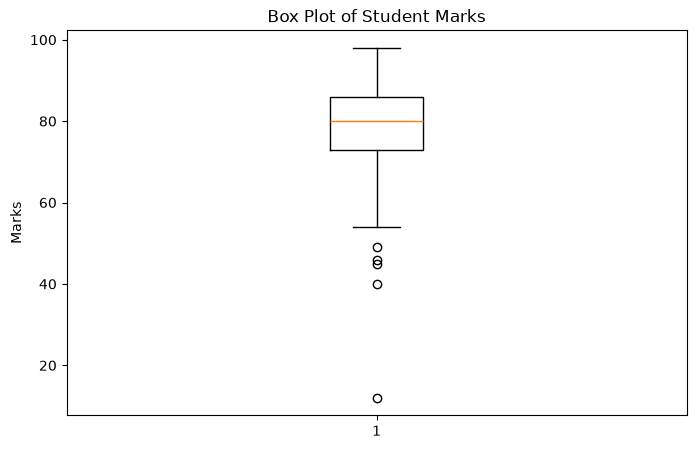

In [422]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(df["marks"])

plt.title("Box Plot of Student Marks")
plt.ylabel("Marks")

plt.show()

##### **Interquartile Range (IQR)**

The Interquartile Range represents the middle 50% of the data.

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1

Potential outliers are identified using:

- Lower Limit = Q1 − 1.5 × IQR
- Upper Limit = Q3 + 1.5 × IQR

In [423]:
Q1 = df["marks"].quantile(0.25)
Q3 = df["marks"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 73.0
Q3: 86.0
IQR: 13.0
Lower Limit: 53.5
Upper Limit: 105.5


In [424]:
potential_outliers = df[
    (df["marks"] < lower_limit) |
    (df["marks"] > upper_limit)
]

potential_outliers

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
24,2024025,Rizwan Khan,male,22.0,CS,4,46.0,52.9,Dera Ismail Khan,2024-04-12,rizwan.khan2024025@rizwan.khan2024025@itar.edu.pk,Yes,15000.0
57,2024058,Kamran Khan,male,20.0,AI,2,40.0,54.1,Bannu,2024-03-06,kamran.khan2024058,No,30000.0
82,2024083,Hassan Ali,male,19.0,IT,3,12.0,87.1,Mardan,2024-05-01,hassan.ali2024083,No,30000.0
105,2024106,Zainab Bibi,female,25.0,SE,8,45.0,87.1,Bannu,2024-03-20,zainab.bibi2024106@zainab.bibi2024106@itar.edu.pk,No,30000.0
118,2024119,Mudassar Ali,male,19.0,DS,3,49.0,87.1,Swat,2024-02-24,mudassar.ali2024119@mudassar.ali2024119@itar.e...,No,30000.0


##### **Interpreting Potential Outliers**

The observations identified above are statistical outliers according to the IQR rule.

However, they should not be removed automatically. Each potential outlier must be considered in the context of the dataset and its business rules.

For example, a value can be statistically unusual while still being a valid observation.

We will investigate the identified observations before deciding whether any treatment is necessary.

##### **8.2 Investigating and Treating Potential Outliers**

The IQR method identifies statistically unusual observations, but these observations are not automatically errors.

We will inspect the potential outliers and decide whether they should be:

- Retained because they are genuine observations
- Corrected if they are confirmed data-entry errors
- Removed only when there is a valid reason

Outlier treatment should always be based on the context of the data rather than the statistical rule alone.

In [425]:
# Review potential outlier records

potential_outliers

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
24,2024025,Rizwan Khan,male,22.0,CS,4,46.0,52.9,Dera Ismail Khan,2024-04-12,rizwan.khan2024025@rizwan.khan2024025@itar.edu.pk,Yes,15000.0
57,2024058,Kamran Khan,male,20.0,AI,2,40.0,54.1,Bannu,2024-03-06,kamran.khan2024058,No,30000.0
82,2024083,Hassan Ali,male,19.0,IT,3,12.0,87.1,Mardan,2024-05-01,hassan.ali2024083,No,30000.0
105,2024106,Zainab Bibi,female,25.0,SE,8,45.0,87.1,Bannu,2024-03-20,zainab.bibi2024106@zainab.bibi2024106@itar.edu.pk,No,30000.0
118,2024119,Mudassar Ali,male,19.0,DS,3,49.0,87.1,Swat,2024-02-24,mudassar.ali2024119@mudassar.ali2024119@itar.e...,No,30000.0


In [426]:
# Display the marks identified as potential outliers

potential_outliers["marks"]

24     46.0
57     40.0
82     12.0
105    45.0
118    49.0
Name: marks, dtype: float64

##### **Outlier Treatment Decision**

After reviewing the potential outliers, we will retain valid extreme observations.

If an observation is confirmed as a data-entry or other data-quality error, it should be corrected using an appropriate rule.

Therefore, statistical outliers will not be automatically deleted or replaced.

##### **8.3 Outlier Detection for Other Numerical Variables**

The IQR method can also be applied to other numerical variables that may contain unusually high or low observations.

In this dataset, we will examine:

- `attendance_percentage`
- `tuition_fee`

These variables have already passed the business-rule validation. Therefore, any observations identified here are potential statistical outliers, not automatically invalid values.

We will identify them using the IQR method and review them before deciding whether treatment is necessary.

In [427]:
# Detect potential outliers using the IQR method

numerical_columns = [
    "marks",
    "attendance_percentage",
    "tuition_fee"
]

outlier_summary = {}

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    outlier_summary[column] = len(outliers)

outlier_summary

{'marks': 5, 'attendance_percentage': 8, 'tuition_fee': 0}

##### **Interpreting the Results**

The summary shows the number of potential statistical outliers detected in each numerical variable.

These observations will not be automatically removed or replaced.

A potential outlier may be a genuine observation, so treatment should only be applied when there is sufficient evidence that the value is incorrect.

#### **9. Date Handling & Feature Extraction**
The `admission_date` column was converted to a proper datetime format during the data type conversion stage.

We will now extract useful date-based features such as:

- Admission year
- Admission month
- Admission day
- Day of week

These derived features can be used for grouping, filtering, visualization, and further analysis.

In [428]:
# Extract useful date components

df["admission_year"] = df["admission_date"].dt.year
df["admission_month"] = df["admission_date"].dt.month
df["admission_day"] = df["admission_date"].dt.day
df["admission_day_name"] = df["admission_date"].dt.day_name()

In [429]:
# Display the admission date and newly created features

df[
    [
        "admission_date",
        "admission_year",
        "admission_month",
        "admission_day",
        "admission_day_name"
    ]
].head()

,admission_date,admission_year,admission_month,admission_day,admission_day_name
0,2024-01-22,2024.0,1.0,22.0,Monday
1,2024-04-30,2024.0,4.0,30.0,Tuesday
2,2024-12-08,2024.0,12.0,8.0,Sunday
3,NaT,NaN,NaN,NaN,NaN
4,2024-01-01,2024.0,1.0,1.0,Monday


##### **Result**

The `admission_date` column is now stored as a datetime variable, and additional date-based features have been created.

These features can be used in later analysis to study admission patterns by year, month, day, or day of the week.

##### **10. Final Data Quality Check**

Before saving the cleaned dataset, a final quality check is performed to confirm that the major data-quality problems have been addressed.

The final check includes:

- Missing values
- Duplicate records
- Data types
- Valid ranges
- Dataset structure

This ensures that the dataset is ready to be saved as the cleaned version.

In [430]:
# Check for remaining missing values

df.isnull().sum()

student_id               0
full_name                0
gender                   0
age                      0
department               0
semester                 0
marks                    0
attendance_percentage    0
city                     0
admission_date           6
email                    0
scholarship              0
tuition_fee              0
admission_year           6
admission_month          6
admission_day            6
admission_day_name       6
dtype: int64

### **Result**

The final missing-value check shows that all columns are complete except `admission_date` and its derived date features.

Six records have missing `admission_date` values. Because the original admission dates are unknown, these values are intentionally retained as missing rather than being replaced with an estimated or artificial date.

The corresponding derived features — `admission_year`, `admission_month`, `admission_day`, and `admission_day_name` — are also missing for these six records because they are calculated directly from `admission_date`.

This is expected behavior and does not represent a data-quality error.

In [431]:
# Verify that missing derived date features correspond to missing admission dates

df[
    df["admission_date"].isnull()
][
    [
        "student_id",
        "admission_date",
        "admission_year",
        "admission_month",
        "admission_day",
        "admission_day_name"
    ]
]

,student_id,admission_date,admission_year,admission_month,admission_day,admission_day_name
3,2024004,NaT,NaN,NaN,NaN,NaN
7,2024008,NaT,NaN,NaN,NaN,NaN
14,2024015,NaT,NaN,NaN,NaN,NaN
18,2024019,NaT,NaN,NaN,NaN,NaN
104,2024105,NaT,NaN,NaN,NaN,NaN
142,2024143,NaT,NaN,NaN,NaN,NaN


### **Interpretation**

The missing values in the derived date features are a direct consequence of the missing `admission_date` values.

Therefore, no additional treatment is required.

The missing dates will be preserved so that the cleaned dataset does not contain artificially created historical information.

In [432]:
# Check for duplicate records

df.duplicated().sum()

np.int64(0)

In [433]:
# Review final data types

df.dtypes

student_id                        int64
full_name                           str
gender                              str
age                             float64
department                          str
semester                          int64
marks                           float64
attendance_percentage           float64
city                                str
admission_date           datetime64[us]
email                               str
scholarship                         str
tuition_fee                     float64
admission_year                  float64
admission_month                 float64
admission_day                   float64
admission_day_name                  str
dtype: object

In [434]:
# Final validation of important numerical and categorical values

print("Invalid age:", (~df["age"].between(18, 25)).sum())
print("Invalid semester:", (~df["semester"].between(1, 8)).sum())
print("Invalid marks:", (~df["marks"].between(0, 100)).sum())
print("Invalid attendance:", (~df["attendance_percentage"].between(0, 100)).sum())
print("Invalid scholarship:", (~df["scholarship"].isin(["Yes", "No"])).sum())
print("Invalid department:", (~df["department"].isin(["CS", "IT", "SE", "AI", "DS"])).sum())
print("Invalid tuition fee:", (df["tuition_fee"] <= 0).sum())

Invalid age: 0
Invalid semester: 0
Invalid marks: 0
Invalid attendance: 0
Invalid scholarship: 0
Invalid department: 0
Invalid tuition fee: 0


In [435]:
# Review the final cleaned dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   student_id             145 non-null    int64         
 1   full_name              145 non-null    str           
 2   gender                 145 non-null    str           
 3   age                    145 non-null    float64       
 4   department             145 non-null    str           
 5   semester               145 non-null    int64         
 6   marks                  145 non-null    float64       
 7   attendance_percentage  145 non-null    float64       
 8   city                   145 non-null    str           
 9   admission_date         139 non-null    datetime64[us]
 10  email                  145 non-null    str           
 11  scholarship            145 non-null    str           
 12  tuition_fee            145 non-null    float64       
 13  admission_year  

In [436]:
print("Final dataset shape:", df.shape)

Final dataset shape: (145, 17)


### **Result**

The final quality checks confirm that the dataset has been reviewed for missing values, duplicate records, data types, and business-rule violations.

All identified data-quality issues have been addressed according to the appropriate cleaning strategy. The remaining missing values in `admission_date` are intentional because the original historical dates are unknown and should not be artificially assigned.

The dataset is now consistent, validated, and ready for further analysis and downstream machine learning workflows.

#### **11. Save Cleaned Dataset**

After completing the data cleaning, validation, outlier investigation, and date preparation steps, the final cleaned dataset is saved for future use.

The cleaned dataset will be stored separately from the original raw dataset.

This preserves the original data and allows the cleaned dataset to be reused in future data analysis and data science workflows.

In [437]:
# Save the cleaned dataset

cleaned_path = "../datasets/cleaned/student_performance_cleaned.csv"

df.to_csv(cleaned_path, index=False)

print(f"Cleaned dataset saved to: {cleaned_path}")

Cleaned dataset saved to: ../datasets/cleaned/student_performance_cleaned.csv


#### **Conclusion**

The raw student performance dataset has been cleaned and prepared through a structured data-quality workflow.

The process included:

- Data inspection
- Data type handling
- Missing-value treatment
- Duplicate detection
- Data validation
- Invalid-value correction
- Outlier detection and investigation
- Date conversion and feature extraction
- Final data-quality validation

The resulting cleaned dataset has been saved separately from the raw dataset and is ready for further data analysis, visualization, and data science workflows.